# OTF Scan --- Diagnostics & Manifest

Load reduced data from `02_scan_load.ipynb`, visualize QA metrics,
inspect survey coverage, and update the survey manifest.

Run `02_scan_load.ipynb` first to generate `reduced_survey.npz`.

In [7]:
import sys; sys.path.insert(0, '..')

if 'utils' in sys.modules:
    del sys.modules['utils']
sys.path.insert(0, '.')

import ugradiolab.plotting as plotting
from ugradiolab.plotting import SS_FINE, LEGEND_SIZE
from plotters import (plot_heatmap, plot_survey_mollweide,
                      add_survey_footprints)

from pathlib import Path
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

## 1. Load reduced data

In [8]:
REDUCED_PATH = Path('../reduced_survey.npz')

with np.load(REDUCED_PATH) as f:
    cell_keys = f['cell_keys']        # (N, 2) int: (l, b)
    R_stack = f['R_stack']            # (N, n_ch) float: R(v_LSR)
    v_lsr = f['v_lsr']               # (n_ch,) float: velocity grid
    dv_kms = float(f['dv_kms'])
    n_pairs = f['n_pairs']           # (N,) int
    n_1420 = f['n_1420']             # (N,) int
    n_1421 = f['n_1421']             # (N,) int
    W_flag = f['W_flag']             # (N,) bool
    peak_v_flag = f['peak_v_flag']   # (N,) bool
    W = f['W']
    peak_R = f['peak_R']
    peak_v = f['peak_v']
    snr = f['snr']
    noise_rms = f['noise_rms']
    W_frac_resid = f['W_frac_resid']
    W_z = f['W_z']
    peak_v_resid = f['peak_v_resid']
    peak_v_z = f['peak_v_z']
    neighbor_count = f['neighbor_count']

gl = cell_keys[:, 0].astype(float)
gb = cell_keys[:, 1].astype(float)
any_flag = W_flag | peak_v_flag

print(f'Loaded {len(cell_keys)} cells, {R_stack.shape[1]} channels')
print(f'Velocity range: [{v_lsr[-1]:.0f}, {v_lsr[0]:.0f}] km/s LSR')
print(f'QA flags: W={W_flag.sum()}, peak_v={peak_v_flag.sum()}, any={any_flag.sum()}')

Loaded 1636 cells, 418 channels
Velocity range: [-144, 76] km/s LSR
QA flags: W=15, peak_v=6, any=21


## 2. QA heatmaps

Fractional W residuals and peak velocity residuals after beam-weighted
local plane fits (computed in `02_scan_load`).

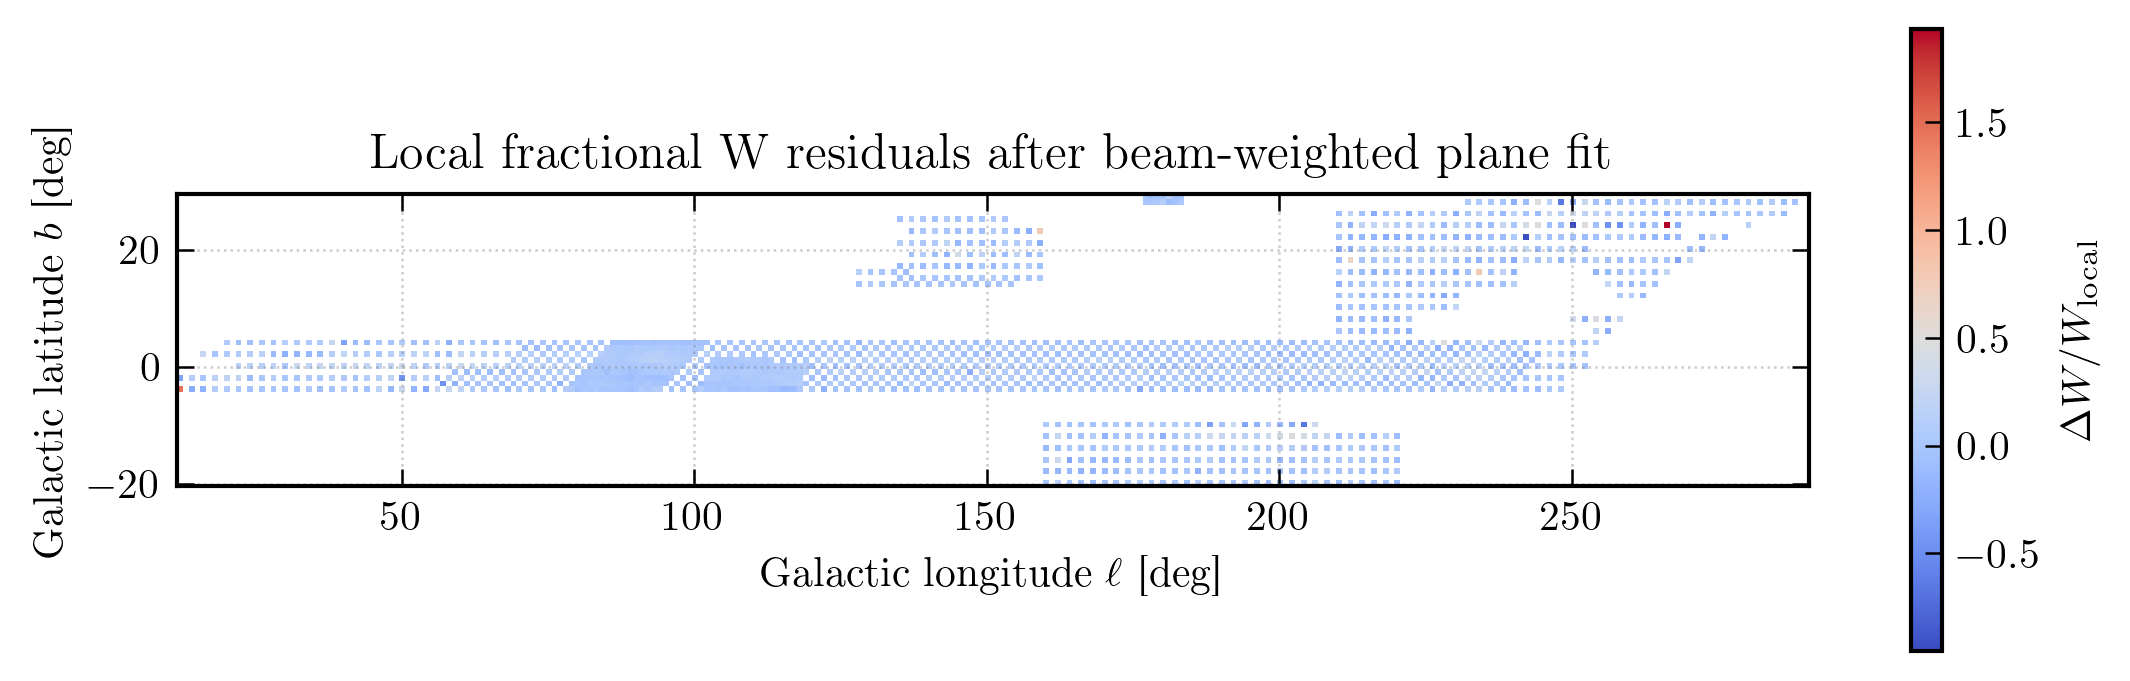

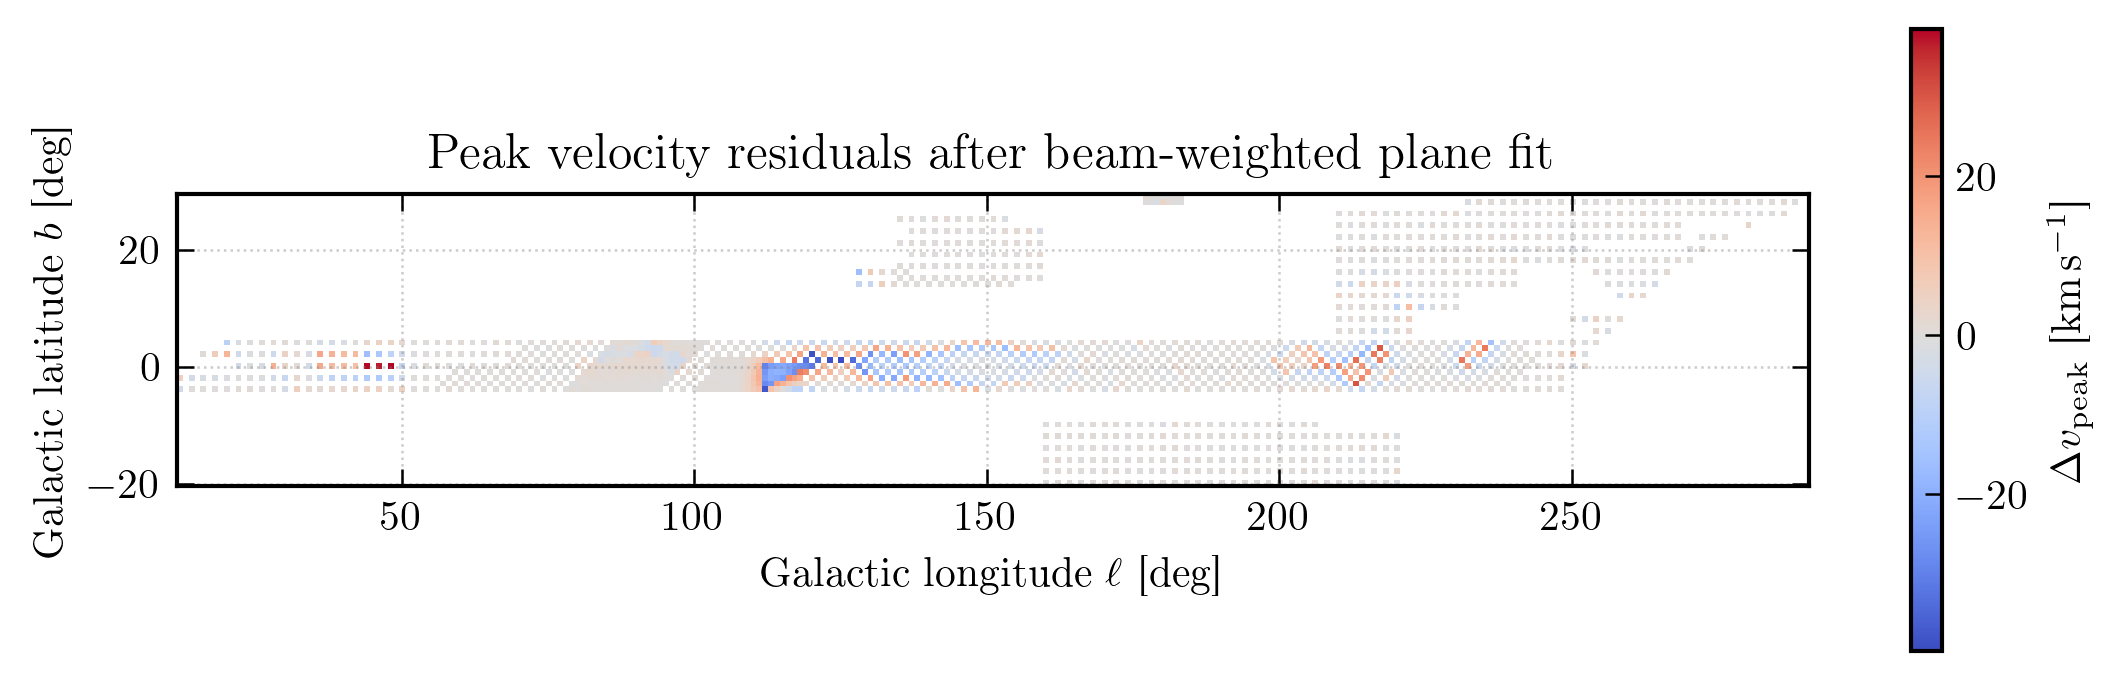

Flagged cells (21):
  l= 12 b= -4 n=5 W frac=+1.46 z=+6.52
  l= 12 b= -2 n=5 W frac=-0.33 z=-5.23
  l= 46 b= +0 n=20 v dv=+36.9 z=+6.19
  l= 57 b= -3 n=16 W frac=-0.47 z=-3.71
  l=114 b= -1 n=53 v dv=-19.0 z=-6.33
  l=123 b= +1 n=34 v dv=-38.6 z=-5.43
  l=125 b= +1 n=33 v dv=-39.8 z=-9.32
  l=128 b=+16 n=6 v dv=-16.0 z=-5.32
  l=145 b=+19 n=20 W frac=+0.38 z=+6.32
  l=159 b=+23 n=7 W frac=+0.76 z=+35.66
  l=162 b=-16 n=17 W frac=+0.32 z=+7.38
  l=194 b=-10 n=12 W frac=-0.31 z=-9.93
  l=208 b= +0 n=36 v dv=+23.1 z=+6.02
  l=212 b=+18 n=17 W frac=+0.65 z=+8.81
  l=234 b=+16 n=17 W frac=+0.78 z=+12.59
  l=242 b=+22 n=20 W frac=-0.93 z=-6.00
  l=250 b= +8 n=6 W frac=+0.36 z=+61.51
  l=250 b=+24 n=20 W frac=-0.95 z=-4.44
  l=258 b=+24 n=17 W frac=-0.46 z=-5.61
  l=266 b=+24 n=15 W frac=+1.93 z=+19.81
  l=268 b=+18 n=9 W frac=-0.33 z=-3.66


In [9]:
fig, ax = plot_heatmap(
    gl, gb, W_frac_resid,
    cbar_label=r"$\Delta W / W_{\mathrm{local}}$",
    cmap="coolwarm",
    title="Local fractional W residuals after beam-weighted plane fit",
)
plt.show()

fig, ax = plot_heatmap(
    gl, gb, peak_v_resid,
    cbar_label=r"$\Delta v_{\mathrm{peak}}$ [km\,s$^{-1}$]",
    cmap="coolwarm",
    title="Peak velocity residuals after beam-weighted plane fit",
)
plt.show()

# List flagged cells
if any_flag.any():
    print(f'Flagged cells ({any_flag.sum()}):')
    for i in np.where(any_flag)[0]:
        flags = []
        if W_flag[i]:
            flags.append(f'W frac={W_frac_resid[i]:+.2f} z={W_z[i]:+.2f}')
        if peak_v_flag[i]:
            flags.append(f'v dv={peak_v_resid[i]:+.1f} z={peak_v_z[i]:+.2f}')
        print(f'  l={cell_keys[i,0]:3d} b={cell_keys[i,1]:+3d} '
              f'n={int(neighbor_count[i])} {"; ".join(flags)}')

## 3. Pointing summary

In [10]:
import pandas as pd

rows_df = []
for i in range(len(cell_keys)):
    rows_df.append({
        'l': cell_keys[i, 0], 'b': cell_keys[i, 1],
        'n_pairs': int(n_pairs[i]),
        'n_1420': int(n_1420[i]),
        'n_1421': int(n_1421[i]),
        'W': W[i],
        'SNR': snr[i],
        'W_flag': bool(W_flag[i]),
        'v_flag': bool(peak_v_flag[i]),
    })

df = pd.DataFrame(rows_df).set_index(['l', 'b'])

print(f'Unique pointings: {len(df)}')
print(f'Total dumps: {df["n_1420"].sum() + df["n_1421"].sum()}')
print(f'Flagged: {any_flag.sum()} ({W_flag.sum()} W, {peak_v_flag.sum()} peak_v)')
print(f'Median SNR: {np.nanmedian(snr):.1f}')
print()
df

Unique pointings: 1636
Total dumps: 13759
Flagged: 21 (15 W, 6 peak_v)
Median SNR: 85.4



n_pairs  n_1420  n_1421          W        SNR  W_flag  v_flag
l   b                                                                 
12  -4         4       4       4  14.137098        NaN    True   False
    -2         4       4       4  16.301448        NaN    True   False
14  -4         4       4       4   9.367112        NaN   False   False
    -2         4       4       4  21.446876        NaN   False   False
16  -4         4       4       4  10.065635        NaN   False   False
...          ...     ...     ...        ...        ...     ...     ...
284  28        4       4       4   6.397467  69.067843   False   False
286  26        4       4       4   5.969434  48.637247   False   False
     28        4       4       4   5.570062  66.497033   False   False
288  28        4       4       4   5.908765  79.926432   False   False
290  28        4       4       5   6.336204  31.119145   False   False

[1636 rows x 7 columns]

## 4. Survey coverage + observability

Mollweide projection showing survey pointings colored by dump count,
overlaid with the never-observable region.

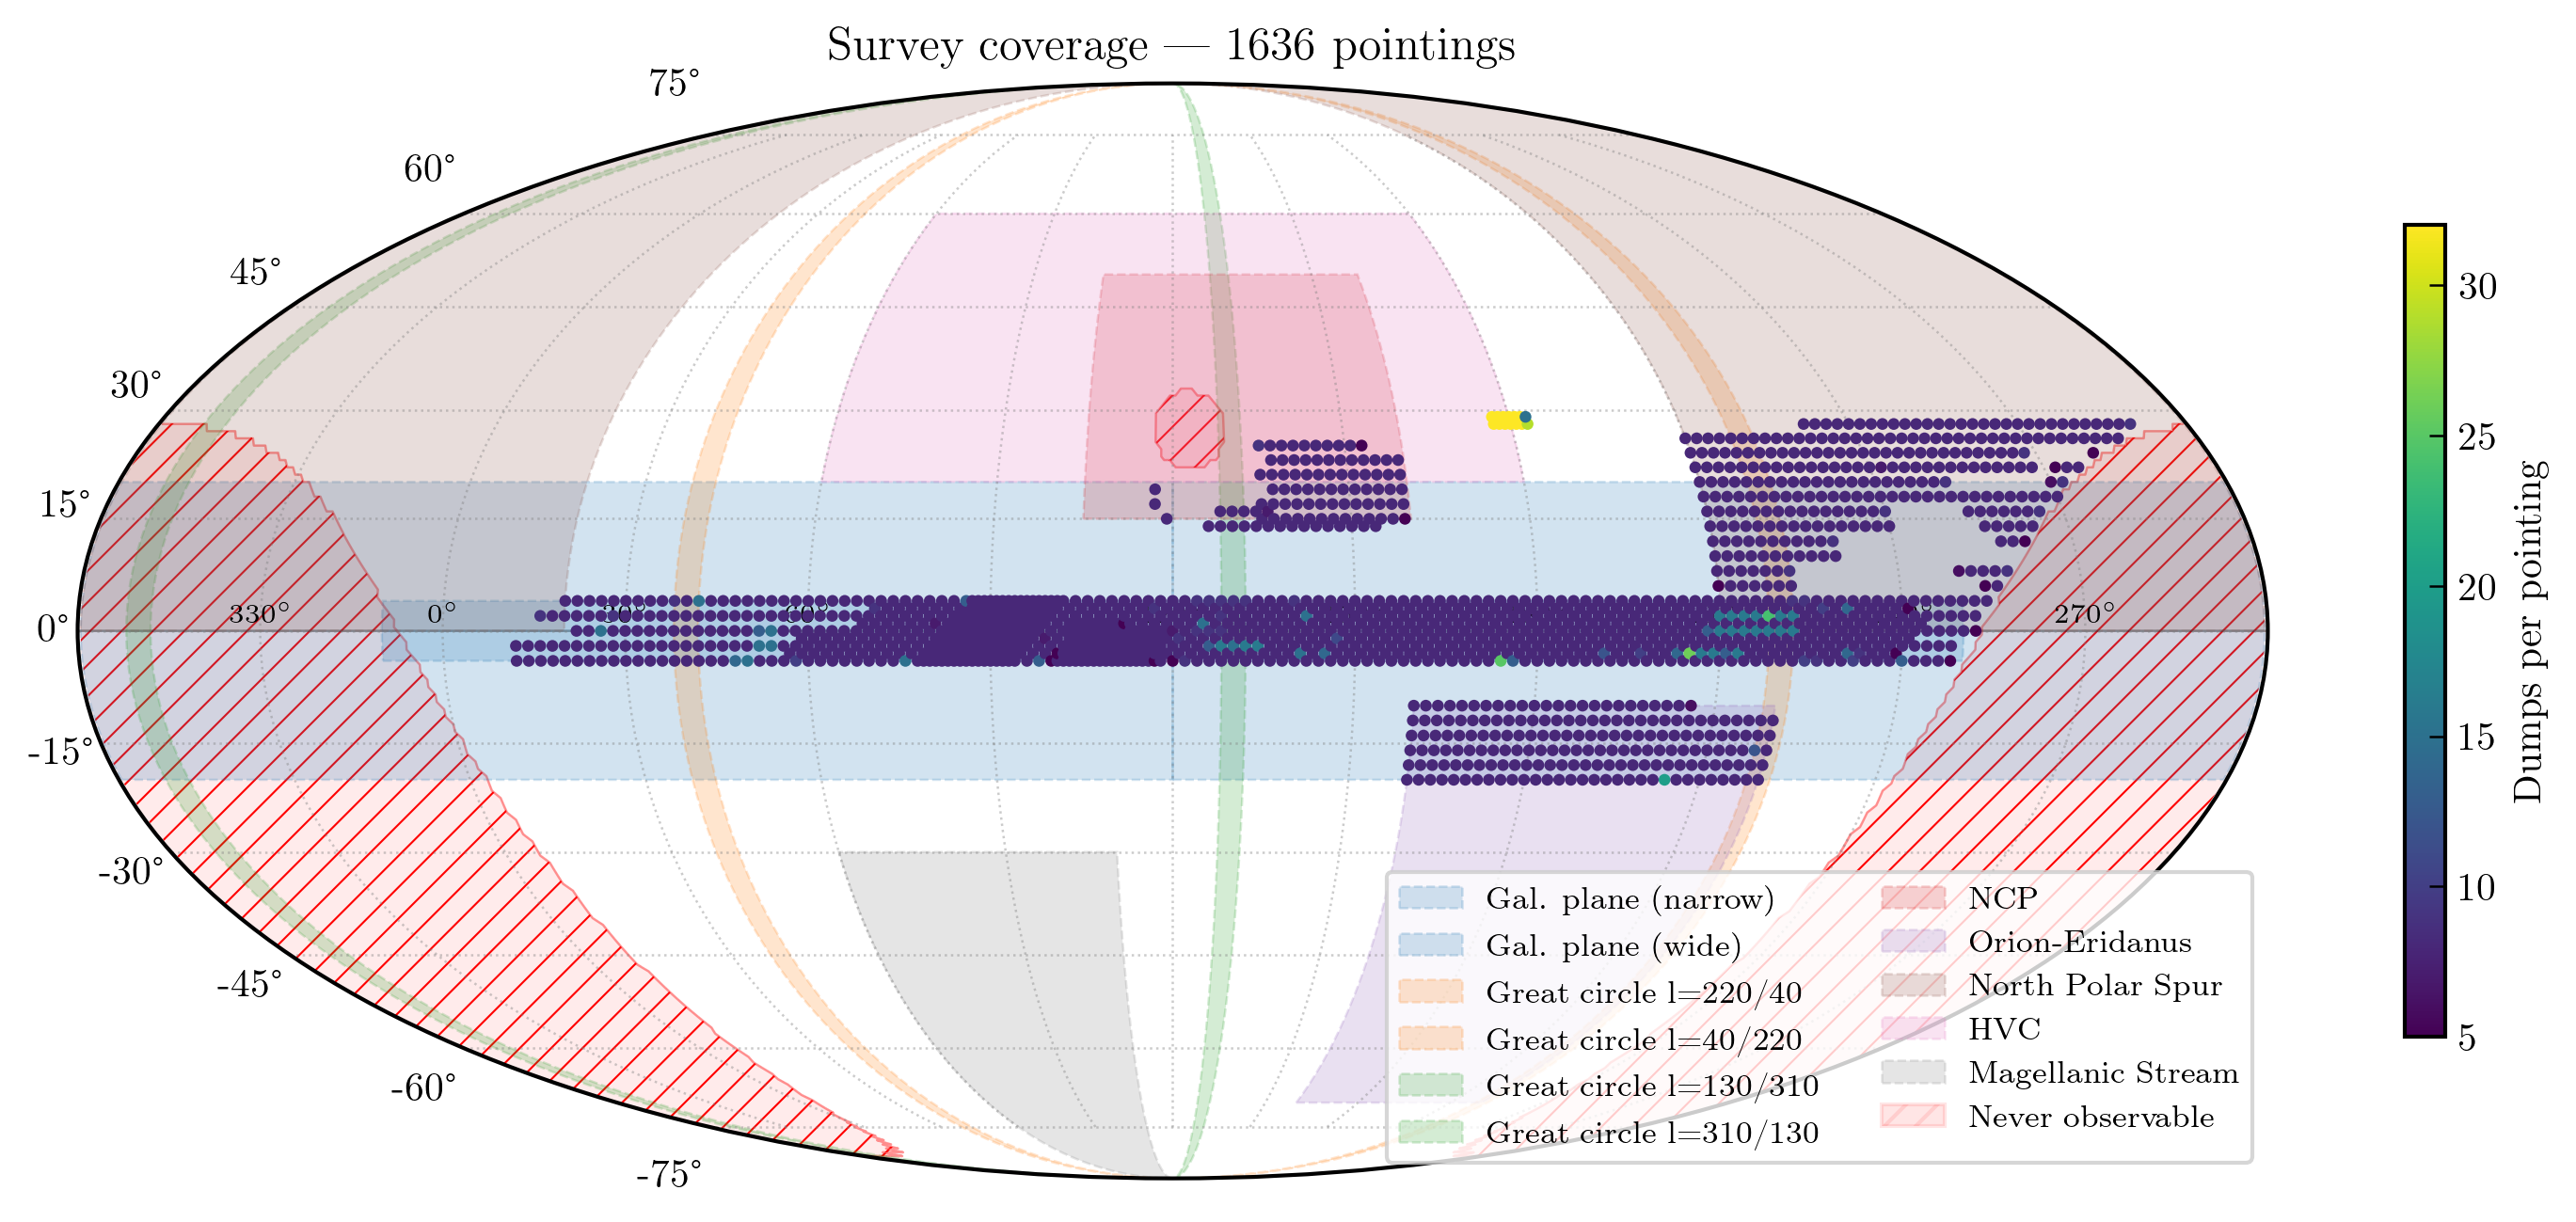

In [11]:
MOLL_CENTER_L = 120.0

n_dumps = n_1420 + n_1421
fig, ax = plot_survey_mollweide(
    gl, gb, n_dumps.astype(float),
    center_l=MOLL_CENTER_L,
    cbar_label="Dumps per pointing",
    cmap="viridis",
    marker_size=SS_FINE,
    title=f'Survey coverage --- {len(cell_keys)} pointings',
)

# Overlay candidate survey footprints
add_survey_footprints(ax, center_l=MOLL_CENTER_L)

# Legend: survey regions + never-observable
handles, labels = ax.get_legend_handles_labels()
handles.append(Rectangle((0, 0), 1, 1, facecolor='red', alpha=0.1,
                          edgecolor='red', hatch='///'))
labels.append('Never observable')
ax.legend(handles, labels, fontsize=LEGEND_SIZE - 1,
          loc='lower right', ncol=2)
plt.show()

## 4b. Example raw spectra (cal-on vs cal-off)

Load one representative pointing's raw dumps to show the noise-diode
calibration effect on each polarization.

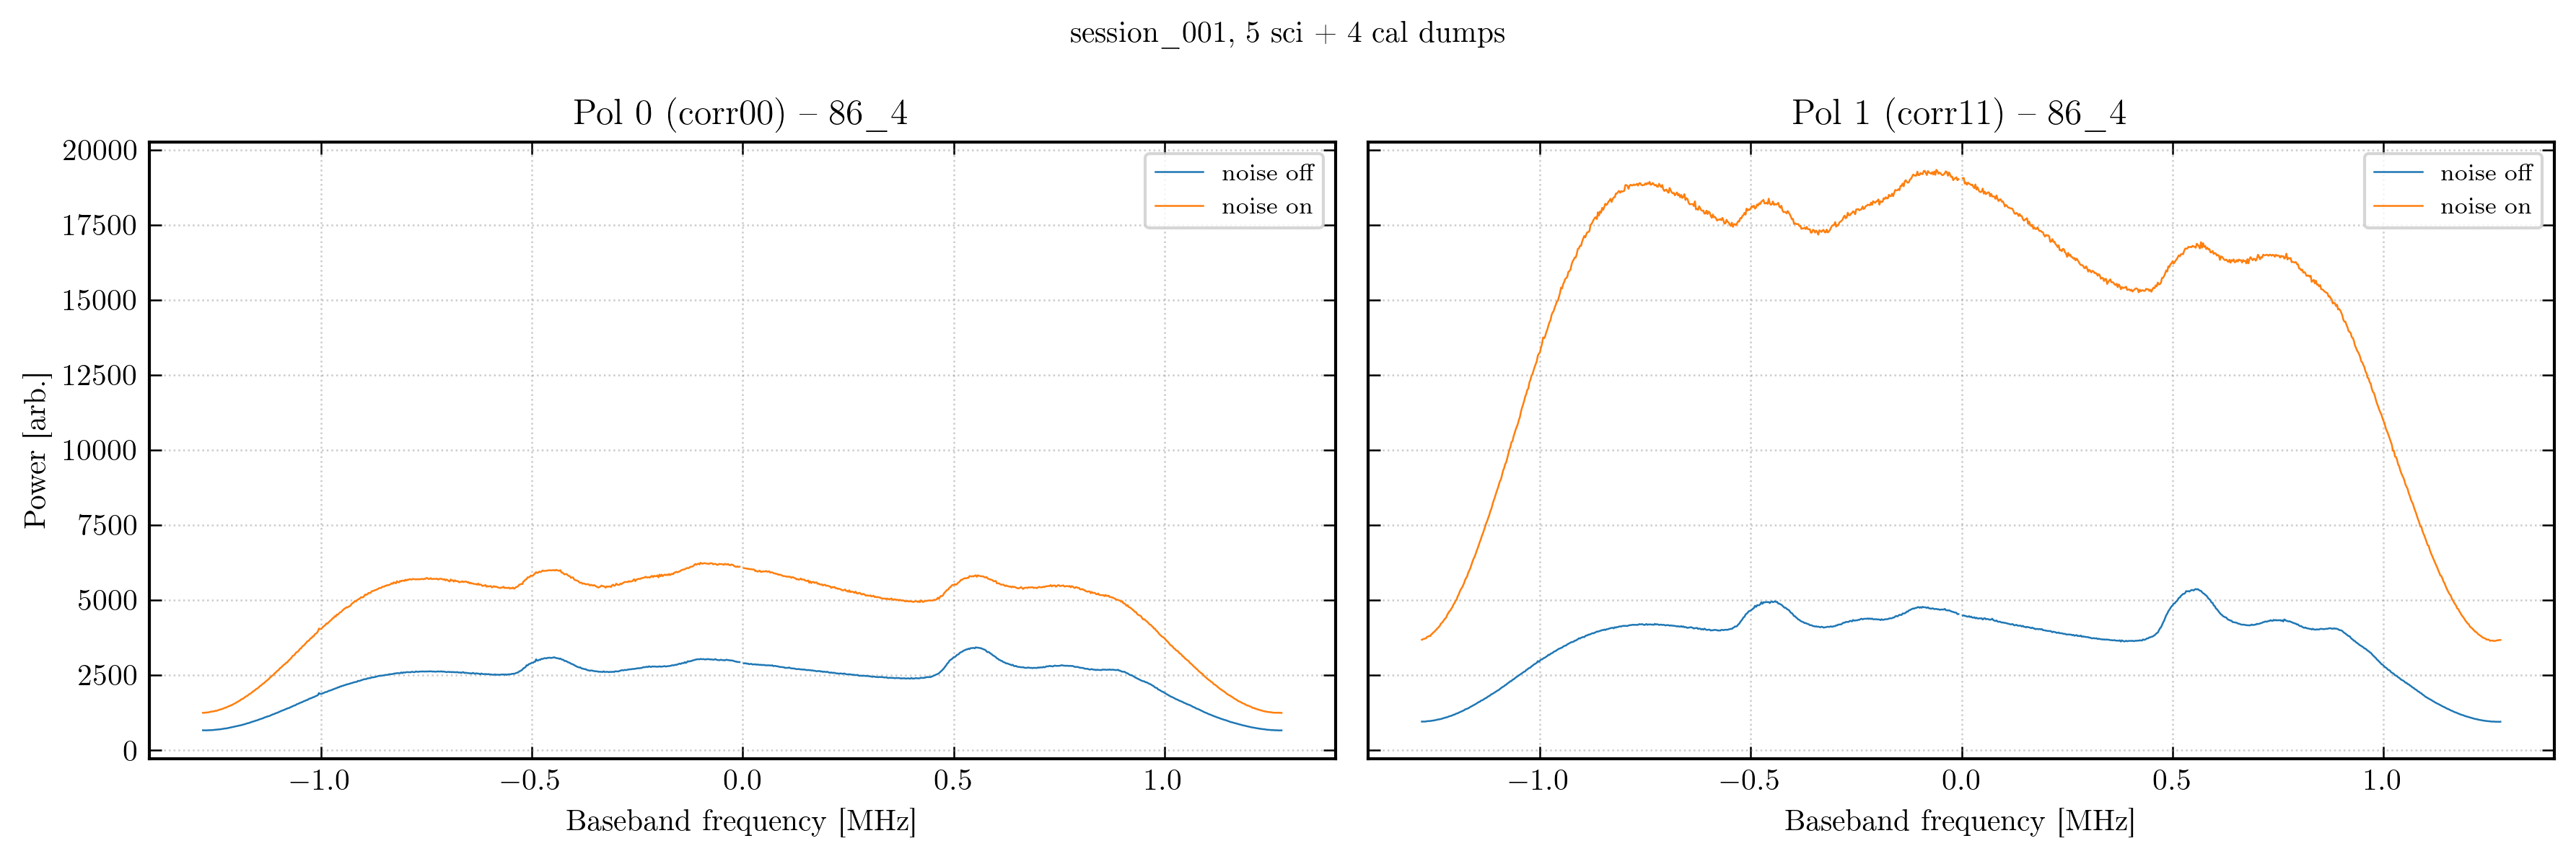

In [12]:
STREAMING_DIR = Path('../../../data/lab04/streaming')
SAMPLE_RATE_HZ = 2.56e6
NFFT = 1024
DC_BIN = NFFT // 2

f_bb_mhz = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1.0 / SAMPLE_RATE_HZ)) / 1e6

# Find a session that has both obs_ and cal_ subdirs for the same cell
obs_files = cal_files = None
cell_label = session_name = ''
for session_dir in sorted(STREAMING_DIR.glob('session_*')):
    cal_dirs = {d.name.replace('cal_', ''): d
                for d in sorted(session_dir.glob('cal_*'))}
    for obs_dir in sorted(session_dir.glob('obs_*')):
        lbl = obs_dir.name.replace('obs_', '')
        if lbl not in cal_dirs:
            continue
        of = sorted(obs_dir.glob('*.npz'))
        cf = sorted(cal_dirs[lbl].glob('*.npz'))
        if len(of) >= 2 and len(cf) >= 1:
            obs_files, cal_files = of, cf
            cell_label = lbl
            session_name = session_dir.name
            break
    if obs_files is not None:
        break

assert obs_files is not None, 'No cell with both obs and cal dumps found'

# Load and average
obs_00, obs_11, cal_00, cal_11 = [], [], [], []
for p in obs_files:
    with np.load(p, allow_pickle=True) as f:
        obs_00.append(np.fft.fftshift(f['corr00'].astype(float)))
        obs_11.append(np.fft.fftshift(f['corr11'].astype(float)))
for p in cal_files:
    with np.load(p, allow_pickle=True) as f:
        cal_00.append(np.fft.fftshift(f['corr00'].astype(float)))
        cal_11.append(np.fft.fftshift(f['corr11'].astype(float)))

P_off_00 = np.nanmean(obs_00, axis=0).copy()
P_off_11 = np.nanmean(obs_11, axis=0).copy()
P_on_00 = np.nanmean(cal_00, axis=0).copy()
P_on_11 = np.nanmean(cal_11, axis=0).copy()

# Mask DC bin region
for arr in (P_off_00, P_off_11, P_on_00, P_on_11):
    arr[DC_BIN - 2 : DC_BIN + 1] = np.nan

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax0.plot(f_bb_mhz, P_off_00, lw=0.6, label='noise off')
ax0.plot(f_bb_mhz, P_on_00, lw=0.6, label='noise on')
ax0.set_xlabel('Baseband frequency [MHz]')
ax0.set_ylabel('Power [arb.]')
ax0.set_title(f'Pol 0 (corr00) -- {cell_label}')
ax0.legend(fontsize=8)

ax1.plot(f_bb_mhz, P_off_11, lw=0.6, label='noise off')
ax1.plot(f_bb_mhz, P_on_11, lw=0.6, label='noise on')
ax1.set_xlabel('Baseband frequency [MHz]')
ax1.set_title(f'Pol 1 (corr11) -- {cell_label}')
ax1.legend(fontsize=8)

fig.suptitle(f'{session_name}, {len(obs_files)} sci + {len(cal_files)} cal dumps',
             fontsize=10)
fig.tight_layout()
plt.show()

## 5. Update survey manifest

Write per-pointing completeness to `survey_manifest.json` from the
reduced data.  QA-flagged cells are excluded so the observation script
will re-observe them.

In [13]:
from manifest import write_manifest, read_manifest

# Build manifest from reduced data, excluding QA-flagged cells
flagged_set = set()
for i in np.where(any_flag)[0]:
    flagged_set.add((int(cell_keys[i, 0]), int(cell_keys[i, 1])))

if flagged_set:
    print(f'Excluding {len(flagged_set)} QA-flagged cells from manifest')

manifest_pointings = {}
for i in range(len(cell_keys)):
    key = (int(cell_keys[i, 0]), int(cell_keys[i, 1]))
    if key in flagged_set:
        continue
    manifest_pointings[key] = {
        'n_1420': int(n_1420[i]),
        'n_1421': int(n_1421[i]),
    }

MANIFEST_PATH = Path('../survey_manifest.json')
write_manifest(manifest_pointings, MANIFEST_PATH)

pointings = read_manifest(MANIFEST_PATH)
incomplete = {lb: info for lb, info in pointings.items() if not info['complete']}
if incomplete:
    print(f'\nIncomplete cells ({len(incomplete)}):')
    print(f'  {"l":>4} {"b":>4} {"pairs":>5} {"target":>6} {"need":>5}')
    for (l, b), info in sorted(incomplete.items()):
        need = info['target'] - info['n_pairs']
        print(f'  {l:>4} {b:>+4} {info["n_pairs"]:>5} {info["target"]:>6} {need:>5}')
else:
    print('\nAll cells complete!')

Excluding 21 QA-flagged cells from manifest
Manifest written: ../survey_manifest.json
  1615 pointings: 1593 complete, 22 incomplete

Incomplete cells (22):
     l    b pairs target  need
    81   +1     3      4     1
    99   -1     3      4     1
   100   -4     2      4     2
   101   -3     2      4     2
   112   +1     2      4     2
   117   -4     2      4     2
   120   -4     2      4     2
   120   +0     3      4     1
   136  +16     3      4     1
   153  +25     2      4     2
   159  +15     2      4     2
   206  -10     3      4     1
   210   +6     2      4     2
   239   -3     2      4     2
   241   +3     2      4     2
   248   -4     2      4     2
   252   +0     2      4     2
   254   +6     2      4     2
   262  +12     2      4     2
   270  +20     3      4     1
   272  +22     2      4     2
   280  +24     2      4     2


## 6. Truncation flagging

Identify cells whose frequency-switched spectrum R(v) is truncated --
the usable (finite) portion does not taper to ~0 at the blue or red
edge.  A positive edge value means HI signal was cut off by
insufficient LSR velocity coverage.

Convention:
- **Red edge**: low channel indices = positive velocities (redward)
- **Blue edge**: high channel indices = negative velocities (blueward)

Flagged cells need follow-up dumps from a shifted LO pair to extend
velocity coverage on the truncated side.

In [14]:
from scipy.stats import median_abs_deviation
from ugradiolab.plotting import (LABEL_SIZE, TICK_SIZE, EMPHASIS_SIZE,
                                  LW_FINE, LW_STANDARD,
                                  ALPHA_STANDARD, ALPHA_LIGHT,
                                  NEUTRAL_COLOR, GRID_STYLE)

EDGE_N = 5  # channels to average at each edge
N_cells = len(cell_keys)

red_edge = np.full(N_cells, np.nan)
blue_edge = np.full(N_cells, np.nan)
v_red = np.full(N_cells, np.nan)
v_blue = np.full(N_cells, np.nan)
n_finite = np.zeros(N_cells, dtype=int)

for i in range(N_cells):
    r = R_stack[i]
    fin = np.where(np.isfinite(r))[0]
    n_finite[i] = len(fin)
    if len(fin) < 2 * EDGE_N:
        continue
    red_edge[i] = np.nanmean(r[fin[:EDGE_N]])
    v_red[i] = v_lsr[fin[0]]
    blue_edge[i] = np.nanmean(r[fin[-EDGE_N:]])
    v_blue[i] = v_lsr[fin[-1]]

v_coverage = np.abs(v_red - v_blue)

# Data-driven threshold: 3-sigma above median (MAD-based)
all_edges = np.concatenate([red_edge[np.isfinite(red_edge)],
                            blue_edge[np.isfinite(blue_edge)]])
edge_median = np.median(all_edges)
edge_sigma = median_abs_deviation(all_edges) * 1.4826
TRUNC_THRESH = edge_median + 3 * edge_sigma

trunc_red = red_edge > TRUNC_THRESH
trunc_blue = blue_edge > TRUNC_THRESH
trunc_any = trunc_red | trunc_blue

print(f'Edge statistics: median = {edge_median:.4f}, sigma(MAD) = {edge_sigma:.4f}')
print(f'Truncation threshold (median + 3*sigma): R > {TRUNC_THRESH:.4f}')
print()
print(f'Truncated red  (positive-v end): {trunc_red.sum()} cells')
print(f'Truncated blue (negative-v end): {trunc_blue.sum()} cells')
print(f'Truncated either end:            {trunc_any.sum()} cells')
print(f'Truncated both ends:             {(trunc_red & trunc_blue).sum()} cells')
print(f'Clean:                           {(~trunc_any).sum()} cells')

Edge statistics: median = 0.0121, sigma(MAD) = 0.0128
Truncation threshold (median + 3*sigma): R > 0.0504

Truncated red  (positive-v end): 321 cells
Truncated blue (negative-v end): 187 cells
Truncated either end:            508 cells
Truncated both ends:             0 cells
Clean:                           1128 cells


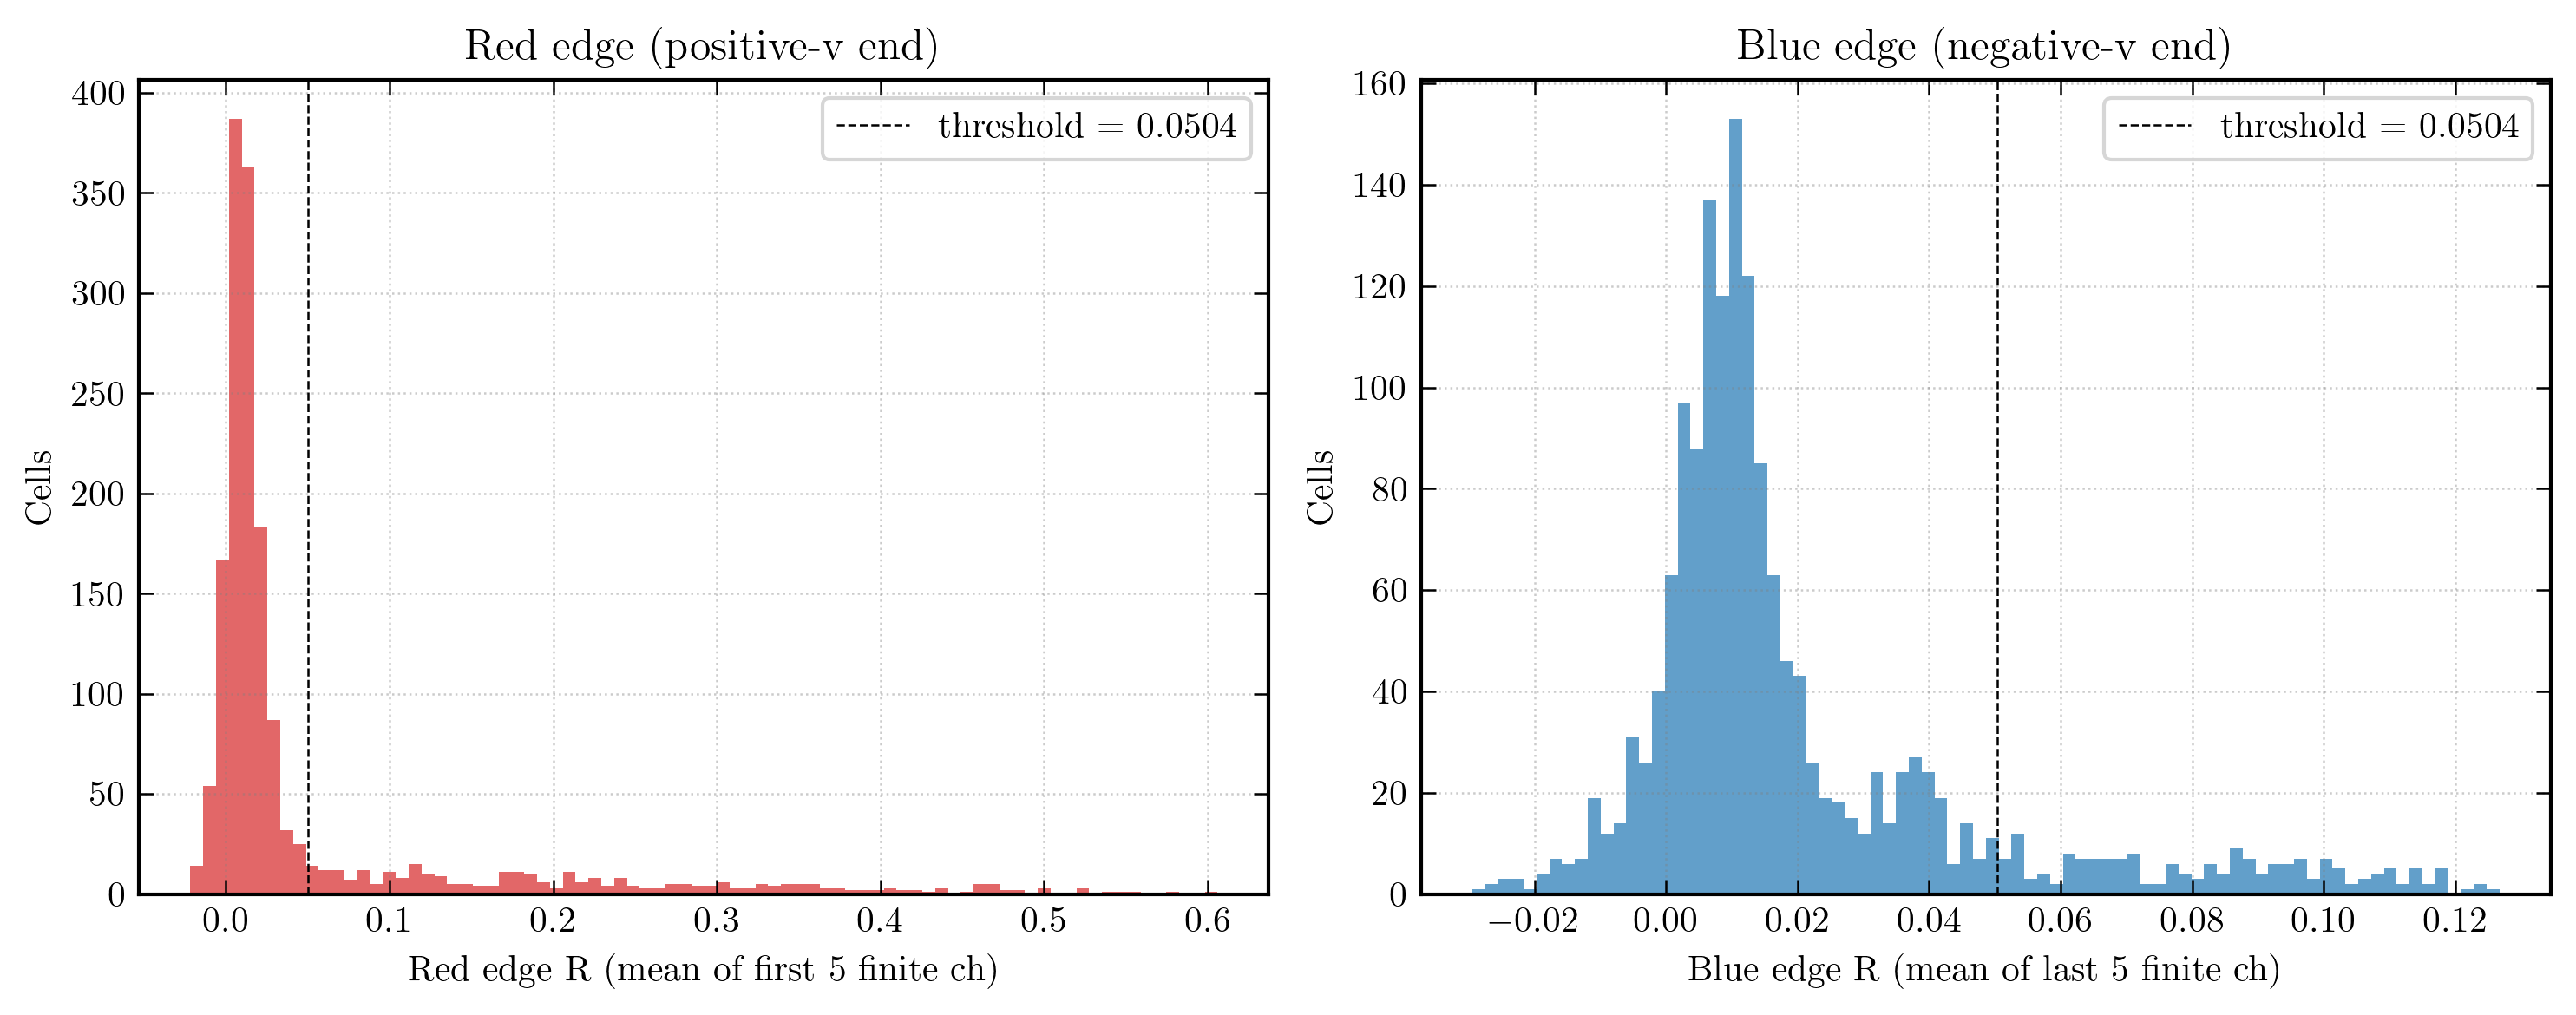

In [15]:
# Edge value distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

valid = np.isfinite(red_edge)
axes[0].hist(red_edge[valid], bins=80, color='C3', alpha=0.7,
             edgecolor='none')
axes[0].axvline(TRUNC_THRESH, color='k', ls='--', lw=LW_FINE,
                label=f'threshold = {TRUNC_THRESH:.4f}')
axes[0].set_xlabel('Red edge R (mean of first 5 finite ch)', fontsize=LABEL_SIZE)
axes[0].set_ylabel('Cells', fontsize=LABEL_SIZE)
axes[0].set_title('Red edge (positive-v end)', fontsize=EMPHASIS_SIZE)
axes[0].legend(fontsize=TICK_SIZE)

valid = np.isfinite(blue_edge)
axes[1].hist(blue_edge[valid], bins=80, color='C0', alpha=0.7,
             edgecolor='none')
axes[1].axvline(TRUNC_THRESH, color='k', ls='--', lw=LW_FINE,
                label=f'threshold = {TRUNC_THRESH:.4f}')
axes[1].set_xlabel('Blue edge R (mean of last 5 finite ch)', fontsize=LABEL_SIZE)
axes[1].set_ylabel('Cells', fontsize=LABEL_SIZE)
axes[1].set_title('Blue edge (negative-v end)', fontsize=EMPHASIS_SIZE)
axes[1].legend(fontsize=TICK_SIZE)

plt.tight_layout()
plt.show()

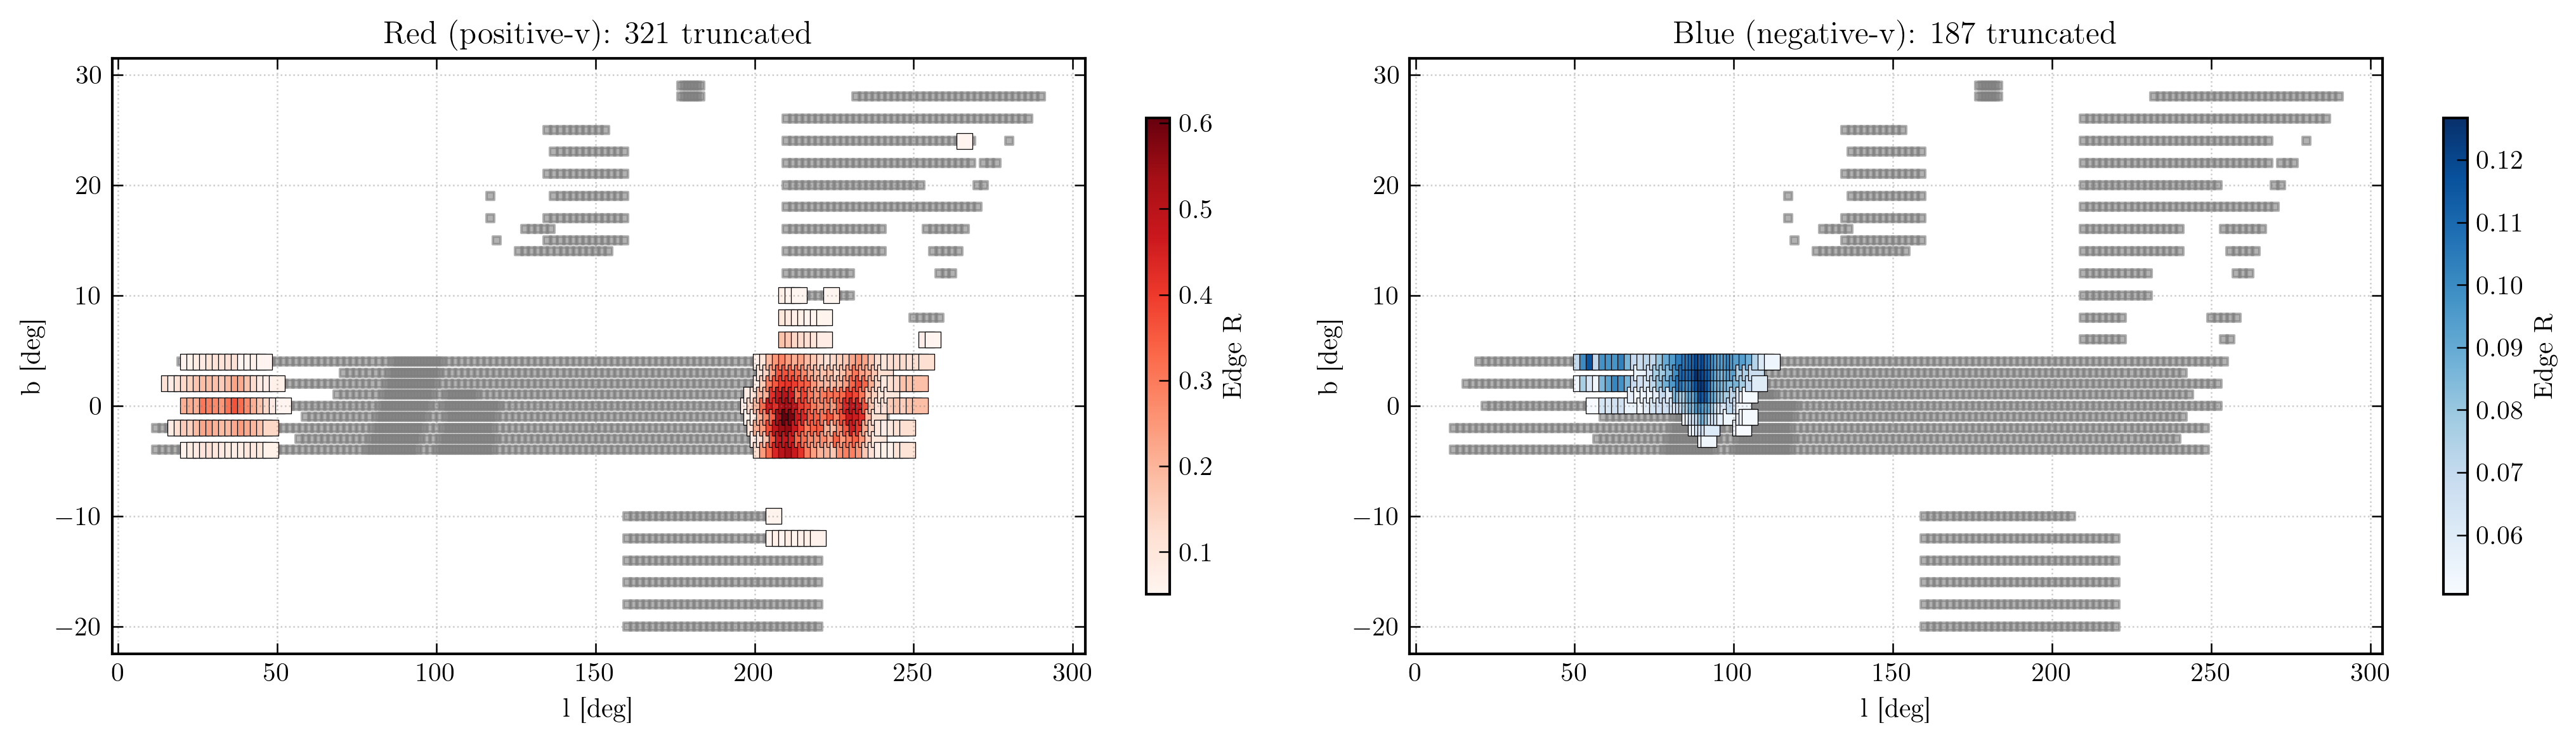

Total cells: 1636
Truncated: 508 (red=321, blue=187, both=0)
  l range: 16 to 266
  b range: -12 to 24


In [16]:
# Spatial distribution of truncated cells
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, edge_val, mask, label, cmap in [
    (axes[0], red_edge, trunc_red, 'Red (positive-v)', 'Reds'),
    (axes[1], blue_edge, trunc_blue, 'Blue (negative-v)', 'Blues'),
]:
    ax.scatter(gl[~mask], gb[~mask], s=SS_FINE, c=NEUTRAL_COLOR,
              alpha=ALPHA_LIGHT, marker='s')
    if mask.any():
        sc = ax.scatter(gl[mask], gb[mask], s=SS_FINE * 4,
                        c=edge_val[mask], cmap=cmap, marker='s',
                        edgecolors='k', linewidths=0.3)
        plt.colorbar(sc, ax=ax, label='Edge R', shrink=0.8)
    ax.set_xlabel('l [deg]', fontsize=LABEL_SIZE)
    ax.set_ylabel('b [deg]', fontsize=LABEL_SIZE)
    ax.set_title(f'{label}: {mask.sum()} truncated', fontsize=EMPHASIS_SIZE)
    ax.grid(**GRID_STYLE)

plt.tight_layout()
plt.show()

# Summary
print(f'Total cells: {N_cells}')
print(f'Truncated: {trunc_any.sum()} '
      f'(red={trunc_red.sum()}, blue={trunc_blue.sum()}, '
      f'both={(trunc_red & trunc_blue).sum()})')
if trunc_any.any():
    trunc_l = cell_keys[trunc_any, 0]
    trunc_b = cell_keys[trunc_any, 1]
    print(f'  l range: {trunc_l.min()} to {trunc_l.max()}')
    print(f'  b range: {trunc_b.min()} to {trunc_b.max()}')

## 7. Update truncation manifest

Write `truncation_manifest.json` for the follow-up observation script
(`scripts/main.py`).  Two regimes:

- **Redwards** (LO 1419/1420 MHz): cells truncated at the positive-velocity end
- **Bluewards** (LO 1420/1421 MHz): cells truncated at the negative-velocity end

Cells truncated at both ends appear in both regimes.

In [17]:
from manifest import write_truncation_manifest

redwards = {}
for i in np.where(trunc_red)[0]:
    l, b = int(cell_keys[i, 0]), int(cell_keys[i, 1])
    redwards[(l, b)] = {'edge_value': float(red_edge[i])}

bluewards = {}
for i in np.where(trunc_blue)[0]:
    l, b = int(cell_keys[i, 0]), int(cell_keys[i, 1])
    bluewards[(l, b)] = {'edge_value': float(blue_edge[i])}

TRUNCATION_MANIFEST_PATH = Path('../truncation_manifest.json')
write_truncation_manifest(redwards, bluewards, TRUNC_THRESH, EDGE_N,
                          TRUNCATION_MANIFEST_PATH)

Truncation manifest written: ../truncation_manifest.json
  Redwards:  321 cells (LO [1419.0, 1420.0])
  Bluewards: 187 cells (LO [1420.0, 1421.0])
